<a href="https://colab.research.google.com/github/sreeja-sakinala/Customer_Data_Analysis/blob/main/Sreeja_Customer_Data_Analysis_for_Business_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#upload the file
from google.colab import files
uploaded = files.upload()

Saving Customer_Master_Data.csv to Customer_Master_Data.csv
Saving Customer_Master_Data.xlsx to Customer_Master_Data.xlsx
Saving Customer_Transactions.csv to Customer_Transactions.csv


In [2]:
#imported the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#data reading
customers = pd.read_csv("Customer_Master_Data.csv")
transactions = pd.read_csv("Customer_Transactions.csv")

In [17]:
#checking the data
customers.head()
transactions.head()

customers.info()
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), obj

In [5]:
#Data Cleaning
# Convert date columns
customers['JoinDate'] = pd.to_datetime(customers['JoinDate'])
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

# Remove duplicates
customers.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

# Handle missing values
customers.fillna("Unknown", inplace=True)
transactions.dropna(inplace=True)

/tmp/ipykernel_1759/3293061181.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])


In [6]:
#merging of data
df = pd.merge(transactions, customers, on='CustomerID', how='left')

df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


Creating RFM Tabel

In [7]:
#refernce_date
reference_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

In [8]:
#RFM Calculation
rfm = df.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,
    'TransactionAmount': ['count', 'sum']
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


In [9]:
#RFM Scores
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [10]:
#Creating Segment
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [11]:
#Creating Categories
def segment(row):
    # Convert R_Score and F_Score to integers for numerical comparison
    r_score_int = int(row['R_Score'])
    f_score_int = int(row['F_Score'])

    if row['RFM_Segment'] == '555':
        return 'Champion'
    elif r_score_int >= 4 and f_score_int >= 4:
        return 'Loyal'
    elif r_score_int <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

Visualization

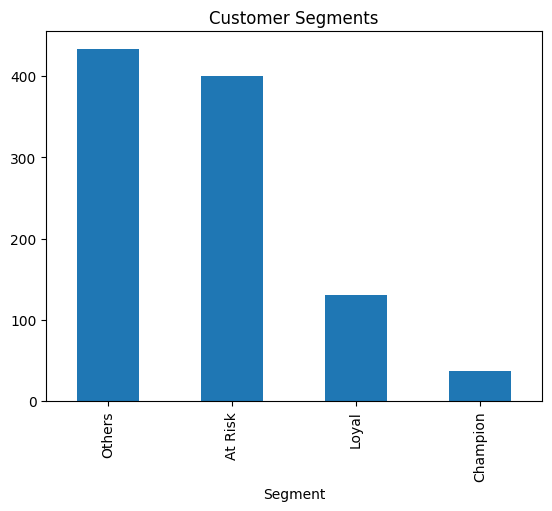

In [12]:
#Customer count segment wise
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

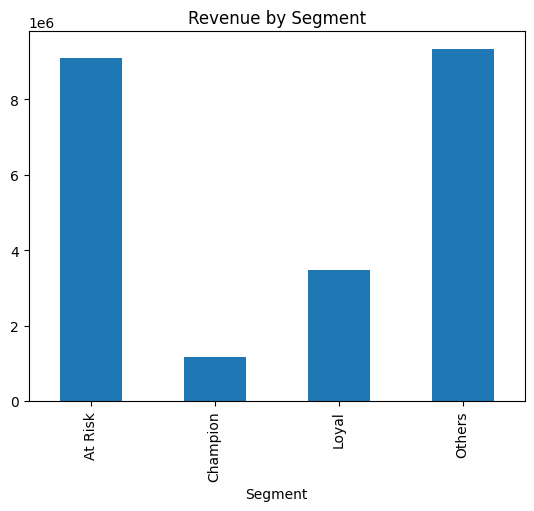

In [13]:
#revenue segment wise
df_merged = pd.merge(df, rfm[['CustomerID','Segment']], on='CustomerID')

df_merged.groupby('Segment')['TransactionAmount'].sum().plot(kind='bar')
plt.title("Revenue by Segment")
plt.show()

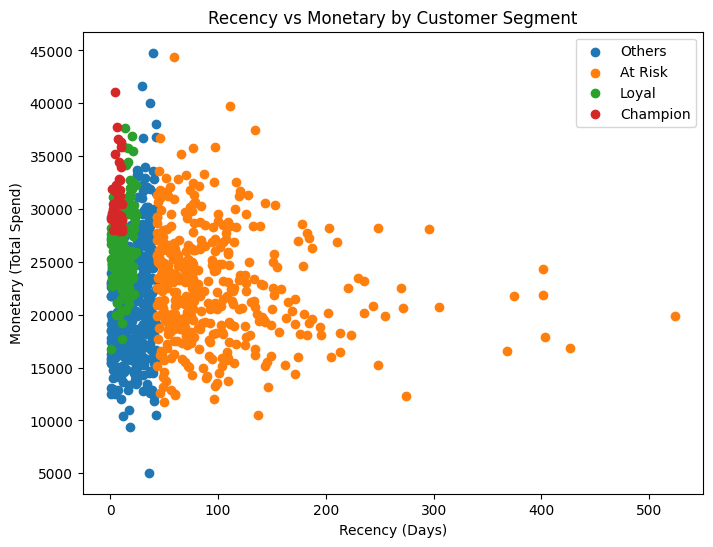

In [14]:
#Recency vs Monetary scatter plot colored by segment
plt.figure(figsize=(8,6))

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]

    plt.scatter(
        subset['Recency'],
        subset['Monetary'],
        label=segment
    )

plt.xlabel("Recency (Days)")
plt.ylabel("Monetary (Total Spend)")
plt.title("Recency vs Monetary by Customer Segment")
plt.legend()
plt.show()


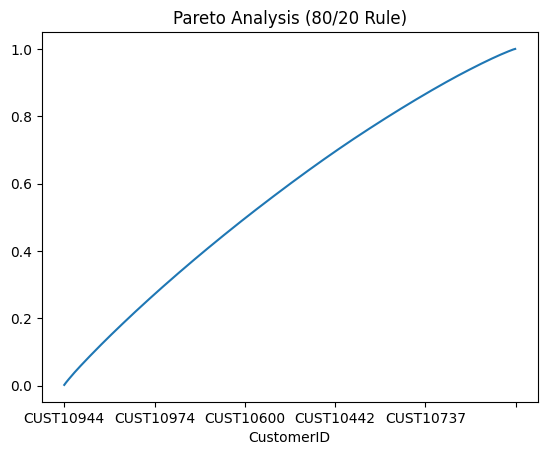

In [15]:
#Pareto Analysis
revenue = df.groupby('CustomerID')['TransactionAmount'].sum().sort_values(ascending=False)

cum_percent = revenue.cumsum() / revenue.sum()

cum_percent.plot()
plt.title("Pareto Analysis (80/20 Rule)")
plt.show()

# **Insights**


The high-value customers should be the primary focus for retention strategies.


Business Recommendation for Champion Customer:

- Provide loyalty rewards

- Offer early access to products/exclusive products
- personalized offers

Business Recommendation for loyal Customer:

- Upsell and cross-sell products for loyal Customer.

- Provide reward points or membership benefits for loyal Customer.

Business Recommendation to keep At-Risk Customers:

- Send re-engagement campaigns and Offer discounts or personalized offers.

- We could also use reminder emails

Recency vs Monetary Insights -
- Customers with low recency (recent buyers) and high monetary value are the most valuable.
- Customers with high recency (inactive) but high monetary value are potential churn risks.
- Customers with low monetary value contribute less regardless of recency.

Some Key Business Takeaways -
- Focus on retaining high-value customers (Champions & Loyal)
- Re-engage At-Risk customers before they churn
- Optimize marketing spend by targeting the right segments
- Use data-driven segmentation for personalized marketing campaigns

In [ ]:
rfm.to_csv("Final_RFM_Output.csv", index=False)